In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
df = pd.read_csv("../data/raw/enron_spam_data.csv")

In [3]:
df.head(10)

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14
6,6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14
7,7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
8,8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14
9,9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14


In [4]:
## Aggressive Duplicate Removal
# We remove duplicates based on the 'Message' content to prevent Train-Test leakage
initial_len = len(df)
df = df.drop_duplicates(subset=['Message']).reset_index(drop=True)
print(f"Removed {initial_len - len(df)} duplicate messages.")
print(f"Final dataset size: {len(df)}")


Removed 17922 duplicate messages.
Final dataset size: 15794


### Drop unnecessary column in dataset

In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.head(10)

,Subject,Message,Spam/Ham,Date
0,christmas tree farm pictures,NaN,ham,1999-12-10
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14
6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14
7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14
9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15794 entries, 0 to 15793
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Subject   15794 non-null  object
 1   Message   15793 non-null  object
 2   Spam/Ham  15794 non-null  object
 3   Date      15794 non-null  object
dtypes: object(4)
memory usage: 493.7+ KB


calculate percentage of empty messages across the dataset

In [8]:
total = len(df)
missing = df["Message"].isna().sum()
ratio = missing/total
ratio*100

np.float64(0.006331518298087882)

Empty-body messages make up only â‰ˆ0.15% of the dataset, so dropping them has negligible impact on data volume or class balanceâ€”safe to remove for the main EDA/modeling pipeline.

In [9]:
empty_df = df[df['Message'].isna() | (df['Message'].str.strip() == '')]


In [10]:
empty_df.head()

,Subject,Message,Spam/Ham,Date
0,christmas tree farm pictures,NaN,ham,1999-12-10


In [11]:
empty_df.to_csv('../data/raw/empty_messages.csv', index=False)

remove row with empty message in dataframe

In [12]:
df_clean = df.drop(empty_df.index).copy() 

In [13]:
df_clean.head()

,Subject,Message,Spam/Ham,Date
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14


In [14]:
df_clean.shape

(15793, 4)

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15793 entries, 1 to 15793
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Subject   15793 non-null  object
 1   Message   15793 non-null  object
 2   Spam/Ham  15793 non-null  object
 3   Date      15793 non-null  object
dtypes: object(4)
memory usage: 493.7+ KB


mapping label

In [16]:
label_map = {'ham': 0, 'spam': 1}
df_clean['label'] = df_clean['Spam/Ham'].str.strip().str.lower().map(label_map)


In [17]:
df_clean.head()

,Subject,Message,Spam/Ham,Date,label
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0


In [18]:
label_counts = df_clean['label'].value_counts(normalize=True)
spam_ratio = label_counts.get(1, 0.0)
ham_ratio = label_counts.get(0, 0.0)
print(spam_ratio)
print(ham_ratio)

0.0
1.0


- Spam makes up 51% vs 49% ham so the classes are fairly balanced

### Length feature

In [19]:
df_clean['message_len'] = df_clean['Message'].str.len()
df_clean['subject_len'] = df_clean['Subject'].str.len()

In [20]:
df_clean.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24
6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21
7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19
8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10
9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22
10,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17


In [21]:
length_stats = df_clean.groupby('label')[['message_len', 'subject_len']].describe()
length_stats

message_len                                                       \
            count         mean          std  min    25%    50%     75%   
label                                                                    
0         15793.0  1603.168936  5412.883472  1.0  317.0  768.0  1647.0   

                subject_len                                               \
            max       count       mean        std  min   25%   50%   75%   
label                                                                      
0      228353.0     15793.0  30.783068  23.997046  1.0  18.0  27.0  41.0   

               
          max  
label          
0      1355.0

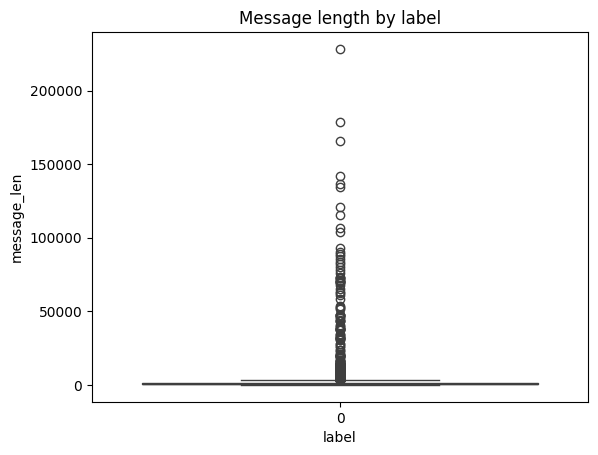

In [22]:
sns.boxplot(data=df_clean, x='label', y='message_len')
plt.title('Message length by label')
plt.show()

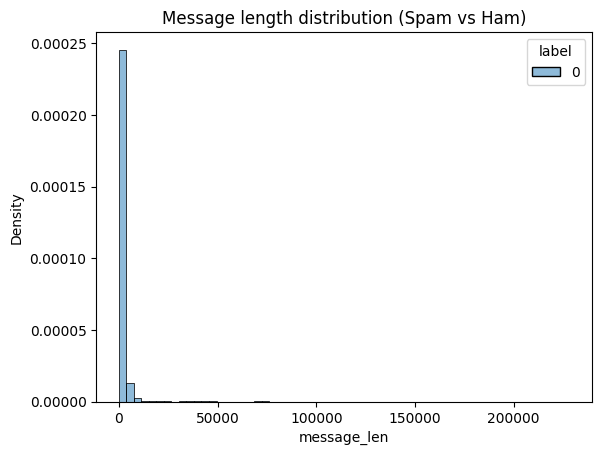

In [23]:
sns.histplot(data=df_clean, x='message_len', hue='label', bins=60, kde=False, stat='density',                
  common_norm=False)                                                                                           
plt.title('Message length distribution (Spam vs Ham)')                                                       
plt.show()   

In [24]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
missing_dates = df_clean['Date'].isna().sum()
print(f"Invalid/missing dates: {missing_dates}")

# Drop rows with invalid dates if any
if missing_dates > 0:
    df_clean = df_clean.dropna(subset=['Date'])

# Feature Engineering: Month, Hour, Weekend
df_clean['month'] = df_clean['Date'].dt.month
df_clean['hour'] = df_clean['Date'].dt.hour
df_clean['is_weekend'] = df_clean['Date'].dt.dayofweek.isin([5, 6]).astype(int)

print("New features added: month, hour, is_weekend")

Invalid/missing dates: 0
New features added: month, hour, is_weekend


In [25]:
daily_counts = df_clean.groupby(df_clean['Date'].dt.date)['label'].agg(['count', 'mean'])                    
daily_counts.rename(columns={'count': 'total', 'mean': 'spam_ratio'}, inplace=True)   
daily_counts

,total,spam_ratio
Date,,
1999-12-10,3,0.0
1999-12-12,1,0.0
1999-12-13,4,0.0
1999-12-14,17,0.0
1999-12-15,11,0.0
...,...,...
2002-03-19,5,0.0
2002-03-20,1,0.0
2002-03-21,3,0.0


In [26]:
weekday_counts = df_clean.groupby(df_clean['Date'].dt.weekday)['label'].agg(['count', 'mean'])
weekday_counts.rename(columns={'count': 'total', 'mean': 'spam_ratio'}, inplace=True)
weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
weekday_counts.index = weekday_counts.index.map(weekday_map.get)
weekday_counts = weekday_counts.reindex(list(weekday_map.values()))
weekday_counts


,total,spam_ratio
Date,,
Mon,3006,0.0
Tue,3095,0.0
Wed,3145,0.0
Thu,3022,0.0
Fri,2855,0.0
Sat,293,0.0
Sun,377,0.0


In [27]:
print(daily_counts.head())                                                                                   
print(weekday_counts)                                                                                        

            total  spam_ratio
Date                         
1999-12-10      3         0.0
1999-12-12      1         0.0
1999-12-13      4         0.0
1999-12-14     17         0.0
1999-12-15     11         0.0
      total  spam_ratio
Date                   
Mon    3006         0.0
Tue    3095         0.0
Wed    3145         0.0
Thu    3022         0.0
Fri    2855         0.0
Sat     293         0.0
Sun     377         0.0


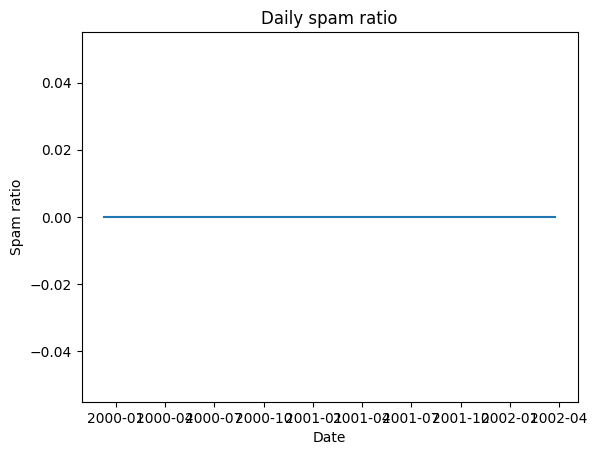

In [28]:
daily_counts['spam_ratio'].plot(kind='line', title='Daily spam ratio')                                       
plt.ylabel('Spam ratio')                                                                                     
plt.show()    

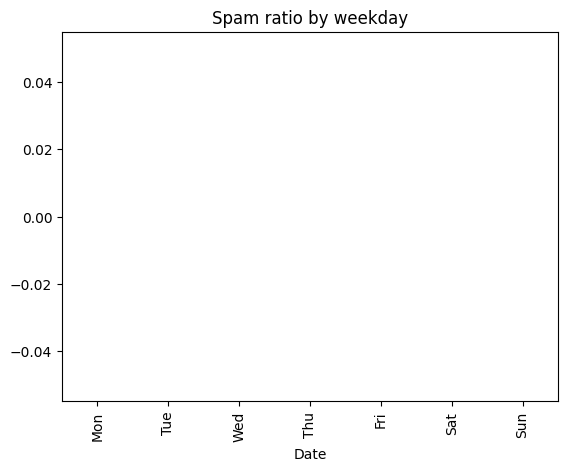

In [29]:
weekday_counts['spam_ratio'].plot(kind='bar', title='Spam ratio by weekday')                                 
plt.show()     

In [30]:
from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True) 


In [31]:
df_clean.to_csv(out_dir / "01_cleaned.csv", index=False)
print(f"Saved cleaned data to {out_dir / '01_cleaned.csv'}")

Saved cleaned data to ..\data\processed\01_cleaned.csv
